# Machine Learning Models

### Imports and Set up

In [17]:
import numpy as np
import pandas as pd
import pickle
import time
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

### Load data

In [3]:
with open('group_5_dataset.pkl', 'rb') as f:
    data = pickle.load(f)

# data format from pickle file:
# 'X_train': (n_train, T, 4),
# 'X_val':   (n_val,   T, 4),
# 'X_test':  (n_test,  T, 4),
# 'y_train': (n_train, 2),   # [R, C]
# 'y_val':   (n_val,   2),
# 'y_test':  (n_test,  2),
# optional: 'mu', 'sigma', 'indices', 'target_is_log'
target_is_log = data.get('target_is_log', False)

# Keep time-series waveforms and scaling stats for Gauss-Newton
X_test_ts = data['X_test']                   # (n_test, T, 4)
mu    = data.get('mu',    None)               # (1, 1, 4) channel means
sigma = data.get('sigma', None)               # (1, 1, 4) channel stds

# flatten out the data from pickle file
X_train = data['X_train'].reshape(data['X_train'].shape[0], -1)  # (n_train, 2000)
X_val = data['X_val'].reshape(data['X_val'].shape[0], -1)        # (n_val, 2000)
X_test = data['X_test'].reshape(data['X_test'].shape[0], -1)     # (n_test, 2000)
y_train = data['y_train']  # (n_train, 2)
y_val = data['y_val']       # (n_val, 2)
y_test = data['y_test']    # (n_test, 2)

### Data preview 

Each sample has **2000 features**: 500 time steps × 4 channels (V1, V2, V3, I_E). At each time step the 4 values are [V1, V2, V3, I_E]. Features 0–3 = first time step, 4–7 = second, etc. Below: first 8 (2 time steps) + targets R (Ω), C (F).

In [29]:
# First 20 rows: first 8 features = first 2 time steps (each step: V1, V2, V3, I_E) + targets
n_display = 20
n_feat = X_train.shape[1]
channel_names = ["V1", "V2", "V3", "I_E"]
n_show = min(8, n_feat)
cols = [f"t{i//4}_{channel_names[i%4]}" for i in range(n_show)]
df_feat = pd.DataFrame(X_train[:n_display, :n_show], columns=cols)
df_targets = pd.DataFrame(y_train[:n_display], columns=["R (ohm)", "C (F)"])
df_preview = pd.concat([df_feat, df_targets], axis=1)
print("First 20 samples (first 2 time steps: t0_V1..t0_I_E, t1_V1..t1_I_E) + targets:")
display(df_preview)
print(f"\nTotal features per sample: {X_train.shape[1]} (500 steps × 4 channels). Target ranges — R: [{y_train[:, 0].min():.2f}, {y_train[:, 0].max():.2f}] Ω,  C: [{y_train[:, 1].min():.2e}, {y_train[:, 1].max():.2e}] F")

First 20 samples (first 2 time steps: t0_V1..t0_I_E, t1_V1..t1_I_E) + targets:


,t0_V1,t0_V2,t0_V3,t0_I_E,t1_V1,t1_V2,t1_V3,t1_I_E,R (ohm),C (F)
0,-0.003269,0.031026,-0.925145,0.394545,0.043481,0.132591,-0.896686,0.409420,6.738612,-15.257172
1,-0.016245,0.010331,-0.940233,0.395156,0.014580,0.069170,-0.912831,0.392038,7.551296,-14.064571
2,0.043841,0.035361,-0.903696,0.394957,0.076210,0.051829,-0.909713,0.395193,7.246409,-13.995175
3,0.007304,0.084272,-0.958441,0.400161,0.063790,0.045778,-0.907941,0.396464,7.217771,-14.025276
4,0.005910,0.070632,-0.902679,0.402762,0.047664,0.054034,-0.927223,0.410611,7.201727,-12.926674
5,0.010445,0.041617,-0.925286,0.397179,0.051957,0.085442,-0.895612,0.385305,7.567712,-12.417433
6,0.012905,0.044780,-0.905386,0.386303,0.057084,0.065452,-0.896447,0.385115,7.458938,-13.243097
7,-0.002115,0.024820,-0.893830,0.398416,0.087966,0.125739,-0.889481,0.378612,6.989643,-12.870809
8,-0.023870,0.039627,-0.905127,0.370614,0.011818,0.052285,-0.914150,0.397832,6.003136,-12.333643
9,0.016910,0.027648,-0.880315,0.407627,0.052752,0.096419,-0.910042,0.383176,7.151654,-12.345269



Total features per sample: 2000 (500 steps × 4 channels). Target ranges — R: [0.24, 7.82] Ω,  C: [-1.61e+01, -1.22e+01] F


### Train / validation / test split

In [4]:
n_train, n_val, n_test = len(X_train), len(X_val), len(X_test)
n_total = n_train + n_val + n_test
split_df = pd.DataFrame({
    "set": ["train", "validation", "test"],
    "samples": [n_train, n_val, n_test],
    "fraction (%)": [100 * n_train / n_total, 100 * n_val / n_total, 100 * n_test / n_total],
})
print("Split (from pickle):")
display(split_df)
print(f"Total samples: {n_total}  |  Features per sample: {X_train.shape[1]}  |  Targets: R, C")

Split (from pickle):


,set,samples,fraction (%)
0,train,1400,70.0
1,validation,300,15.0
2,test,300,15.0


Total samples: 2000  |  Features per sample: 2000  |  Targets: R, C


## 1. Linear regression

**Hyperparameter tuning:** We use **Ridge regression** (linear model with L2 regularization) and tune the regularization strength `alpha` on the validation set. For each configuration we record train, validation, and test MAE and RMSE (for R and C), training time, and data quantity. The best configuration is chosen by validation accuracy (lowest average validation MAE across R and C).

In [29]:
target_is_log = globals().get('target_is_log', False)
y_train_phys = np.exp(y_train) if target_is_log else y_train
y_val_phys = np.exp(y_val) if target_is_log else y_val
y_test_phys = np.exp(y_test) if target_is_log else y_test

def to_phys(y_pred, is_log):
    return np.exp(y_pred) if is_log else y_pred

def metrics_r_c(y_true, y_pred):
    mae_r = mean_absolute_error(y_true[:, 0], y_pred[:, 0])
    mae_c = mean_absolute_error(y_true[:, 1], y_pred[:, 1])
    rmse_r = np.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))
    rmse_c = np.sqrt(mean_squared_error(y_true[:, 1], y_pred[:, 1]))
    mape_r = mean_absolute_percentage_error(y_true[:, 0], y_pred[:, 0]) * 100
    mape_c = mean_absolute_percentage_error(y_true[:, 1], y_pred[:, 1]) * 100
    return mae_r, mae_c, rmse_r, rmse_c, mape_r, mape_c

n_train, n_val, n_test = len(X_train), len(X_val), len(X_test)
alpha_list = [1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0, 100.0]
lr_results = []
best_val_mae_avg = float('inf')
lr_model = None
train_time_lr = None
best_lr_params = {}

for alpha in alpha_list:
    model = Ridge(alpha=alpha, random_state=42)
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    t_elapsed = time.perf_counter() - t0
    y_train_pred = to_phys(model.predict(X_train), target_is_log)
    y_val_pred   = to_phys(model.predict(X_val),   target_is_log)
    y_test_pred  = to_phys(model.predict(X_test),  target_is_log)
    tr = metrics_r_c(y_train_phys, y_train_pred)
    va = metrics_r_c(y_val_phys,   y_val_pred)
    te = metrics_r_c(y_test_phys,  y_test_pred)
    val_mae_avg = (va[0] + va[1]) / 2
    lr_results.append({
        'alpha': alpha,
        'train_time_s': t_elapsed,
        'train_mae_r': tr[0], 'train_mae_c': tr[1],
        'train_rmse_r': tr[2], 'train_rmse_c': tr[3],
        'train_mape_r': tr[4], 'train_mape_c': tr[5],
        'val_mae_r': va[0], 'val_mae_c': va[1],
        'val_rmse_r': va[2], 'val_rmse_c': va[3],
        'val_mape_r': va[4], 'val_mape_c': va[5],
        'test_mae_r': te[0], 'test_mae_c': te[1],
        'test_rmse_r': te[2], 'test_rmse_c': te[3],
        'test_mape_r': te[4], 'test_mape_c': te[5],
    })
    if val_mae_avg < best_val_mae_avg:
        best_val_mae_avg = val_mae_avg
        lr_model = model
        train_time_lr = t_elapsed
        best_lr_params = {'alpha': alpha}

lr_experiments_df = pd.DataFrame(lr_results)
print("Linear Regression (Ridge) — hyperparameter tuning experiments")
print(f"Data: n_train={n_train}, n_val={n_val}, n_test={n_test}")
print("Note: best config selected by validation MAE only; test metrics shown for reference.")
c_cols_lr = [c for c in lr_experiments_df.columns if '_mae_c' in c or '_rmse_c' in c]
r_cols_lr  = [c for c in lr_experiments_df.columns if ('_mae_r' in c or '_rmse_r' in c)]
mape_cols_lr = [c for c in lr_experiments_df.columns if '_mape_' in c]
t_cols_lr  = ['train_time_s']
fmt_lr = {col: "{:.4e}" for col in c_cols_lr}
fmt_lr.update({col: "{:.4f}" for col in r_cols_lr})
fmt_lr.update({col: "{:.2f}%" for col in mape_cols_lr})
fmt_lr.update({col: "{:.4f}" for col in t_cols_lr})
display(lr_experiments_df.style.format(fmt_lr))
print(f"\nBest config (by validation MAE): {best_lr_params}")
print("Justification: Chosen alpha minimizes average validation MAE (R and C).")
print("\nBest model — Val and Test metrics:")
y_val_pred  = to_phys(lr_model.predict(X_val),  target_is_log)
y_test_pred = to_phys(lr_model.predict(X_test), target_is_log)
va = metrics_r_c(y_val_phys,  y_val_pred)
te = metrics_r_c(y_test_phys, y_test_pred)
print(f"  Train time: {train_time_lr:.4f} s")
print(f"  Val:  R mae: {va[0]:.4f}  C mae: {va[1]:.4e}  R rmse: {va[2]:.4f}  C rmse: {va[3]:.4e}  R mape: {va[4]:.2f}%  C mape: {va[5]:.2f}%")
print(f"  Test: R mae: {te[0]:.4f}  C mae: {te[1]:.4e}  R rmse: {te[2]:.4f}  C rmse: {te[3]:.4e}  R mape: {te[4]:.2f}%  C mape: {te[5]:.2f}%")


Linear Regression (Ridge) — hyperparameter tuning experiments
Data: n_train=1400, n_val=300, n_test=300
Note: best config selected by validation MAE only; test metrics shown for reference.


,alpha,train_time_s,train_mae_r,train_mae_c,train_rmse_r,train_rmse_c,train_mape_r,train_mape_c,val_mae_r,val_mae_c,val_rmse_r,val_rmse_c,val_mape_r,val_mape_c,test_mae_r,test_mae_c,test_rmse_r,test_rmse_c,test_mape_r,test_mape_c
0,0.000100,0.0678,0.0584,7.4584e-11,0.0859,1.3292e-10,0.00%,0.01%,142.4504,2.3959e-07,200.2643,5.0750e-07,14.22%,18.87%,147.5221,2.1146e-07,209.2876,4.0022e-07,14.02%,17.36%
1,0.001000,0.1268,0.5712,7.3065e-10,0.8394,1.3022e-09,0.04%,0.06%,141.3274,2.3803e-07,198.5824,5.0574e-07,14.10%,18.73%,146.3168,2.0993e-07,207.8456,3.9828e-07,13.91%,17.24%
2,0.010000,0.1124,4.7319,6.1502e-09,6.9610,1.0947e-08,0.36%,0.50%,132.1962,2.2555e-07,185.2685,4.9137e-07,13.17%,17.71%,136.8242,1.9811e-07,196.5346,3.8503e-07,13.00%,16.32%
3,0.100000,0.0585,21.0839,2.8522e-08,31.2931,5.0427e-08,1.62%,2.41%,103.8737,1.8215e-07,142.0263,4.3138e-07,10.37%,14.72%,109.0920,1.6293e-07,160.6166,3.6124e-07,10.38%,13.72%
4,1.000000,0.0513,51.4473,6.6989e-08,78.1770,1.3001e-07,4.22%,6.41%,79.1693,1.3785e-07,111.1425,3.5050e-07,7.82%,13.15%,94.1966,1.4024e-07,137.9576,3.5513e-07,8.74%,12.49%
5,10.000000,0.0401,105.2429,1.3058e-07,169.7442,3.5279e-07,9.85%,13.43%,108.5209,1.2800e-07,163.4219,3.1104e-07,10.27%,15.70%,115.0336,1.9270e-07,182.5126,5.2894e-07,11.14%,15.83%
6,100.000000,0.0561,169.1017,2.2331e-07,264.0954,5.3193e-07,16.73%,22.85%,162.2094,1.9748e-07,243.7796,4.6276e-07,15.70%,23.05%,165.6914,2.7144e-07,253.9192,7.2568e-07,16.44%,22.72%



Best config (by validation MAE): {'alpha': 1.0}
Justification: Chosen alpha minimizes average validation MAE (R and C).

Best model — Val and Test metrics:
  Train time: 0.0513 s
  Val:  R mae: 79.1693  C mae: 1.3785e-07  R rmse: 111.1425  C rmse: 3.5050e-07  R mape: 7.82%  C mape: 13.15%
  Test: R mae: 94.1966  C mae: 1.4024e-07  R rmse: 137.9576  C rmse: 3.5513e-07  R mape: 8.74%  C mape: 12.49%


In [32]:
from sklearn.metrics import mean_absolute_percentage_error

mape_r = mean_absolute_percentage_error(y_test_phys[:, 0], y_test_pred[:, 0]) * 100
mape_c = mean_absolute_percentage_error(y_test_phys[:, 1], y_test_pred[:, 1]) * 100

print(f"Test MAPE R: {mape_r:.2f}%")
print(f"Test MAPE C: {mape_c:.2f}%")

Test MAPE R: 8.74%
Test MAPE C: 12.49%


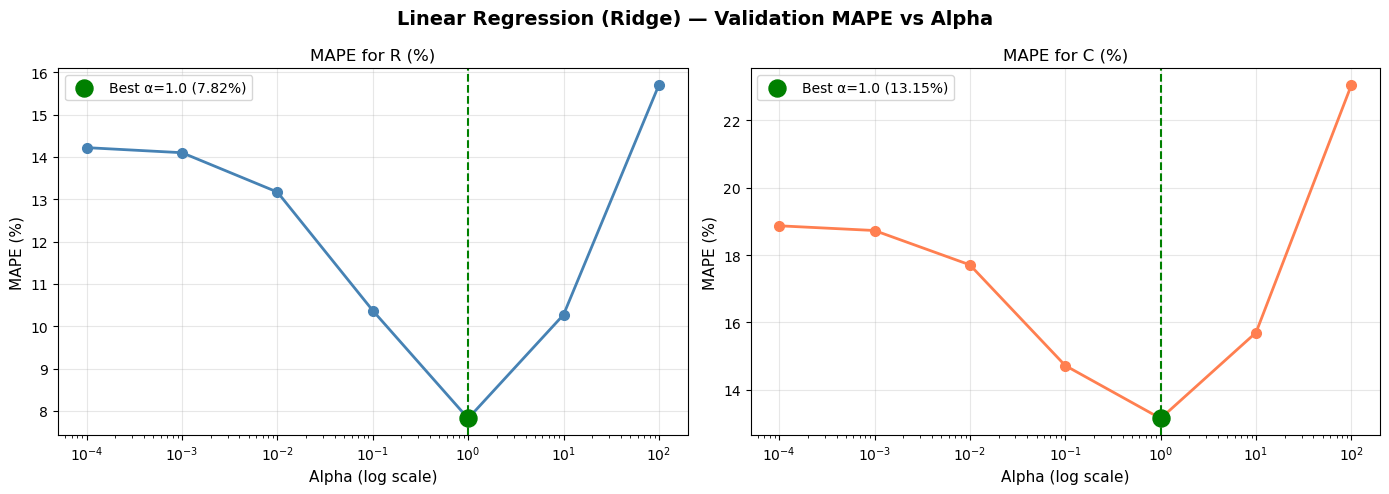

In [30]:
import matplotlib.pyplot as plt
import numpy as np

alphas = [1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0, 100.0]
val_mape_r = [14.22, 14.10, 13.17, 10.37, 7.82, 10.27, 15.70]
val_mape_c = [18.87, 18.73, 17.71, 14.72, 13.15, 15.70, 23.05]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Linear Regression (Ridge) — Validation MAPE vs Alpha', fontsize=14, fontweight='bold')

best_idx = 4  # alpha=1.0

for ax, mape, title, color in zip(
    [ax1, ax2],
    [val_mape_r, val_mape_c],
    ['MAPE for R (%)', 'MAPE for C (%)'],
    ['steelblue', 'coral']
):
    ax.semilogx(alphas, mape, 'o-', color=color, linewidth=2, markersize=7)
    ax.scatter([1.0], [mape[best_idx]], color='green', zorder=5, s=150, label=f'Best α=1.0 ({mape[best_idx]:.2f}%)')
    ax.axvline(x=1.0, color='green', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Alpha (log scale)', fontsize=11)
    ax.set_ylabel('MAPE (%)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('linear_regression_mape.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Random forest

**Hyperparameter tuning:** We tune `n_estimators` and `max_depth` on the validation set. For each configuration we record train, validation, and test MAE and RMSE (for R and C), training time, and data quantity. The best configuration is selected by validation accuracy (lowest average validation MAE across R and C).

In [19]:
target_is_log = globals().get('target_is_log', False)
y_train_phys = np.exp(y_train) if target_is_log else y_train
y_val_phys = np.exp(y_val) if target_is_log else y_val
y_test_phys = np.exp(y_test) if target_is_log else y_test

def to_phys(y_pred, is_log):
    return np.exp(y_pred) if is_log else y_pred

def metrics_r_c(y_true, y_pred):
    mae_r = mean_absolute_error(y_true[:, 0], y_pred[:, 0])
    mae_c = mean_absolute_error(y_true[:, 1], y_pred[:, 1])
    rmse_r = np.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))
    rmse_c = np.sqrt(mean_squared_error(y_true[:, 1], y_pred[:, 1]))
    mape_r = mean_absolute_percentage_error(y_true[:, 0], y_pred[:, 0]) * 100
    mape_c = mean_absolute_percentage_error(y_true[:, 1], y_pred[:, 1]) * 100
    return mae_r, mae_c, rmse_r, rmse_c, mape_r, mape_c

n_train, n_val, n_test = len(X_train), len(X_val), len(X_test)
n_estimators_list = [10, 50, 100, 200]
max_depth_list = [5, 10, 20, None]
rf_results = []
best_model = None
best_val_mae_avg = float('inf')
best_rf_params = {}
train_time_rf = None

for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        t_elapsed = time.perf_counter() - t0
        y_train_pred = to_phys(model.predict(X_train), target_is_log)
        y_val_pred   = to_phys(model.predict(X_val),   target_is_log)
        y_test_pred  = to_phys(model.predict(X_test),  target_is_log)
        tr = metrics_r_c(y_train_phys, y_train_pred)
        va = metrics_r_c(y_val_phys,   y_val_pred)
        te = metrics_r_c(y_test_phys,  y_test_pred)
        val_mae_avg = (va[0] + va[1]) / 2
        rf_results.append({
            'n_estimators': n_estimators,
            'max_depth': str(max_depth),
            'train_time_s': t_elapsed,
            'train_mae_r': tr[0], 'train_mae_c': tr[1],
            'train_rmse_r': tr[2], 'train_rmse_c': tr[3],
            'train_mape_r': tr[4], 'train_mape_c': tr[5],
            'val_mae_r': va[0], 'val_mae_c': va[1],
            'val_rmse_r': va[2], 'val_rmse_c': va[3],
            'val_mape_r': va[4], 'val_mape_c': va[5],
            'test_mae_r': te[0], 'test_mae_c': te[1],
            'test_rmse_r': te[2], 'test_rmse_c': te[3],
            'test_mape_r': te[4], 'test_mape_c': te[5],
        })
        if val_mae_avg < best_val_mae_avg:
            best_val_mae_avg = val_mae_avg
            best_model = model
            best_rf_params = {'n_estimators': n_estimators, 'max_depth': max_depth}
            train_time_rf = t_elapsed

rf_experiments_df = pd.DataFrame(rf_results)
print("Random Forest — hyperparameter tuning experiments")
print(f"Data: n_train={n_train}, n_val={n_val}, n_test={n_test}")
print("Note: best config selected by validation MAE only; test metrics shown for reference.")
c_cols_rf = [c for c in rf_experiments_df.columns if '_mae_c' in c or '_rmse_c' in c]
r_cols_rf  = [c for c in rf_experiments_df.columns if ('_mae_r' in c or '_rmse_r' in c)]
mape_cols_rf = [c for c in rf_experiments_df.columns if '_mape_' in c]
t_cols_rf  = ['train_time_s']
fmt_rf = {col: "{:.4e}" for col in c_cols_rf}
fmt_rf.update({col: "{:.4f}" for col in r_cols_rf})
fmt_rf.update({col: "{:.2f}%" for col in mape_cols_rf})
fmt_rf.update({col: "{:.4f}" for col in t_cols_rf})
display(rf_experiments_df.style.format(fmt_rf))
print(f"\nBest config (by validation MAE): {best_rf_params}")
print("Justification: Chosen n_estimators and max_depth minimize average validation MAE (R and C).")
print("\nBest model — Val and Test metrics:")
y_val_pred  = to_phys(best_model.predict(X_val),  target_is_log)
y_test_pred = to_phys(best_model.predict(X_test), target_is_log)
va = metrics_r_c(y_val_phys,  y_val_pred)
te = metrics_r_c(y_test_phys, y_test_pred)
print(f"  Train time: {train_time_rf:.4f} s")
print(f"  Val:  R mae: {va[0]:.4f}  C mae: {va[1]:.4e}  R rmse: {va[2]:.4f}  C rmse: {va[3]:.4e}  R mape: {va[4]:.2f}%  C mape: {va[5]:.2f}%")
print(f"  Test: R mae: {te[0]:.4f}  C mae: {te[1]:.4e}  R rmse: {te[2]:.4f}  C rmse: {te[3]:.4e}  R mape: {te[4]:.2f}%  C mape: {te[5]:.2f}%")


Random Forest — hyperparameter tuning experiments
Data: n_train=1400, n_val=300, n_test=300
Note: best config selected by validation MAE only; test metrics shown for reference.


,n_estimators,max_depth,train_time_s,train_mae_r,train_mae_c,train_rmse_r,train_rmse_c,train_mape_r,train_mape_c,val_mae_r,val_mae_c,val_rmse_r,val_rmse_c,val_mape_r,val_mape_c,test_mae_r,test_mae_c,test_rmse_r,test_rmse_c,test_mape_r,test_mape_c
0,10,5,6.0153,121.2879,1.7103e-07,172.8115,3.4294e-07,10.35%,12.96%,119.2595,1.5558e-07,174.8219,3.4677e-07,9.76%,14.65%,119.1751,2.2664e-07,168.0037,4.6848e-07,10.90%,16.02%
1,10,10,9.2219,20.2268,4.2421e-08,29.3839,1.2810e-07,2.27%,4.50%,37.1827,7.8878e-08,56.0578,2.6220e-07,3.87%,9.62%,34.2096,1.0189e-07,47.5943,3.1950e-07,4.50%,9.90%
2,10,20,9.3932,19.1538,3.9486e-08,27.4512,1.2641e-07,2.18%,4.25%,38.6299,7.6460e-08,57.2967,2.6297e-07,4.13%,9.12%,36.2830,1.1258e-07,49.4797,3.3356e-07,4.50%,10.10%
3,10,None,9.5057,19.1538,3.9486e-08,27.4512,1.2641e-07,2.18%,4.25%,38.6299,7.6460e-08,57.2967,2.6297e-07,4.13%,9.12%,36.2830,1.1258e-07,49.4797,3.3356e-07,4.50%,10.10%
4,50,5,29.4953,122.5490,1.5612e-07,175.2178,3.2007e-07,10.09%,11.73%,121.6188,1.4105e-07,178.0672,3.3009e-07,9.86%,13.17%,120.9190,2.1273e-07,170.8014,4.3893e-07,10.97%,14.92%
5,50,10,45.0143,13.6766,3.2490e-08,20.4900,1.0868e-07,1.42%,3.43%,26.9644,6.3928e-08,43.2890,2.3836e-07,2.72%,8.08%,24.5155,9.0758e-08,34.7141,2.9214e-07,3.19%,8.77%
6,50,20,47.4735,11.8917,3.0485e-08,17.6909,1.0788e-07,1.29%,3.31%,26.8510,6.7994e-08,42.9590,2.3947e-07,2.81%,8.43%,23.9600,9.2786e-08,34.6582,2.9776e-07,3.01%,8.71%
7,50,None,46.8869,11.8917,3.0485e-08,17.6909,1.0788e-07,1.29%,3.31%,26.8510,6.7994e-08,42.9590,2.3947e-07,2.81%,8.43%,23.9600,9.2786e-08,34.6582,2.9776e-07,3.01%,8.71%
8,100,5,58.7988,120.0820,1.5789e-07,172.9084,3.2371e-07,9.82%,11.75%,120.2650,1.4148e-07,176.2725,3.3259e-07,9.74%,13.03%,120.5021,2.1238e-07,169.9987,4.4472e-07,10.83%,14.81%
9,100,10,90.3609,12.2952,3.0116e-08,19.2110,1.0275e-07,1.20%,3.30%,25.4440,6.2730e-08,42.2519,2.3810e-07,2.45%,7.84%,21.9669,8.8906e-08,32.9012,2.9600e-07,2.74%,8.60%



Best config (by validation MAE): {'n_estimators': 200, 'max_depth': 20}
Justification: Chosen n_estimators and max_depth minimize average validation MAE (R and C).

Best model — Val and Test metrics:
  Train time: 187.1967 s
  Val:  R mae: 22.7260  C mae: 6.3017e-08  R rmse: 39.4937  C rmse: 2.3585e-07  R mape: 2.22%  C mape: 8.14%
  Test: R mae: 20.5594  C mae: 8.8333e-08  R rmse: 31.0981  C rmse: 2.9178e-07  R mape: 2.64%  C mape: 8.64%


In [20]:
from sklearn.metrics import mean_absolute_percentage_error

mape_r = mean_absolute_percentage_error(y_test_phys[:, 0], y_test_pred[:, 0]) * 100
mape_c = mean_absolute_percentage_error(y_test_phys[:, 1], y_test_pred[:, 1]) * 100

print(f"  Test MAPE R: {mape_r:.2f}%")
print(f"  Test MAPE C: {mape_c:.2f}%")

  Test MAPE R: 2.64%
  Test MAPE C: 8.64%


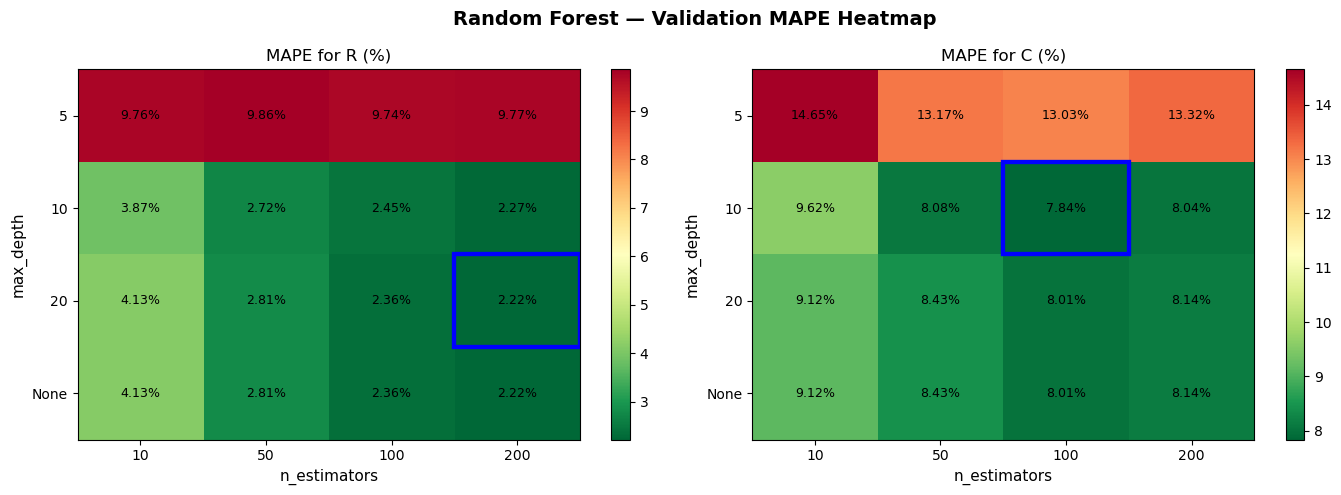

In [23]:


# val MAPE data (rows = max_depth, cols = n_estimators)
val_mape_r = np.array([
    [9.76, 9.86, 9.74, 9.77],   # max_depth=5
    [3.87, 2.72, 2.45, 2.27],   # max_depth=10
    [4.13, 2.81, 2.36, 2.22],   # max_depth=20
    [4.13, 2.81, 2.36, 2.22],   # max_depth=None
])

val_mape_c = np.array([
    [14.65, 13.17, 13.03, 13.32],  # max_depth=5
    [9.62,  8.08,  7.84,  8.04],   # max_depth=10
    [9.12,  8.43,  8.01,  8.14],   # max_depth=20
    [9.12,  8.43,  8.01,  8.14],   # max_depth=None
])

n_estimators_labels = ['10', '50', '100', '200']
max_depth_labels = ['5', '10', '20', 'None']

# best configuration: n_estimators=200, max_depth=20 (lowest avg mape)
best_col_r = 3  # n_estimators=200
best_row_r = 2  # max_depth=20
best_col_c = 2  # n_estimators=200
best_row_c = 1  # max_depth=20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Validation MAPE Heatmap', fontsize=14, fontweight='bold')

for ax, data, title in zip(
    [ax1, ax2],
    [val_mape_r, val_mape_c],
    ['MAPE for R (%)', 'MAPE for C (%)']
):
    im = ax.imshow(data, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(n_estimators_labels)))
    ax.set_yticks(range(len(max_depth_labels)))
    ax.set_xticklabels(n_estimators_labels)
    ax.set_yticklabels(max_depth_labels)
    ax.set_xlabel('n_estimators', fontsize=11)
    ax.set_ylabel('max_depth', fontsize=11)
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax)

    # annotate each cell
    for i in range(len(max_depth_labels)):
        for j in range(len(n_estimators_labels)):
            ax.text(j, i, f'{data[i,j]:.2f}%',
                   ha='center', va='center', fontsize=9, color='black')

    # highlight best cell
    ax1.add_patch(plt.Rectangle(
        (best_col_r - 0.5, best_row_r - 0.5), 1, 1,
        fill=False, edgecolor='blue', linewidth=3
    ))
    
    # highlight best cell
    ax2.add_patch(plt.Rectangle(
        (best_col_c - 0.5, best_row_c - 0.5), 1, 1,
        fill=False, edgecolor='blue', linewidth=3
    ))

plt.tight_layout()
plt.savefig('random_forest_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. MLP

**Hyperparameter tuning:** We tune `hidden_layer_sizes` and L2 regularization `alpha` on the validation set. For each configuration we record train, validation, and test MAE and RMSE (for R and C), training time, and data quantity. The best configuration is selected by validation accuracy (lowest average validation MAE across R and C).

In [24]:
target_is_log = globals().get('target_is_log', False)
y_train_phys = np.exp(y_train) if target_is_log else y_train
y_val_phys = np.exp(y_val) if target_is_log else y_val
y_test_phys = np.exp(y_test) if target_is_log else y_test

def to_phys(y_pred, is_log):
    return np.exp(y_pred) if is_log else y_pred

def metrics_r_c(y_true, y_pred):
    mae_r = mean_absolute_error(y_true[:, 0], y_pred[:, 0])
    mae_c = mean_absolute_error(y_true[:, 1], y_pred[:, 1])
    rmse_r = np.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))
    rmse_c = np.sqrt(mean_squared_error(y_true[:, 1], y_pred[:, 1]))
    mape_r = mean_absolute_percentage_error(y_true[:, 0], y_pred[:, 0]) * 100
    mape_c = mean_absolute_percentage_error(y_true[:, 1], y_pred[:, 1]) * 100
    return mae_r, mae_c, rmse_r, rmse_c, mape_r, mape_c


n_train, n_val, n_test = len(X_train), len(X_val), len(X_test)
hidden_sizes_list = [(64, 32), (128, 64), (256, 128, 64)]
alpha_list = [1e-4, 1e-3, 1e-2]
mlp_results = []
mlp_model = None
best_val_mae_avg = float('inf')
best_mlp_params = {}
train_time_mlp = None

for hidden in hidden_sizes_list:
    for alpha in alpha_list:
        model = MLPRegressor(
            hidden_layer_sizes=hidden,
            activation='relu',
            solver='adam',
            alpha=alpha,
            max_iter=500,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
        )
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        t_elapsed = time.perf_counter() - t0
        y_train_pred = to_phys(model.predict(X_train), target_is_log)
        y_val_pred   = to_phys(model.predict(X_val),   target_is_log)
        y_test_pred  = to_phys(model.predict(X_test),  target_is_log)
        tr = metrics_r_c(y_train_phys, y_train_pred)
        va = metrics_r_c(y_val_phys,   y_val_pred)
        te = metrics_r_c(y_test_phys,  y_test_pred)
        val_mae_avg = (va[0] + va[1]) / 2
        mlp_results.append({
            'hidden_layer_sizes': str(hidden),
            'alpha': alpha,
            'train_time_s': t_elapsed,
            'train_mae_r': tr[0], 'train_mae_c': tr[1],
            'train_rmse_r': tr[2], 'train_rmse_c': tr[3],
            'train_mape_r': tr[4], 'train_mape_c': tr[5],
            'val_mae_r': va[0], 'val_mae_c': va[1],
            'val_rmse_r': va[2], 'val_rmse_c': va[3],
            'val_mape_r': va[4], 'val_mape_c': va[5],
            'test_mae_r': te[0], 'test_mae_c': te[1],
            'test_rmse_r': te[2], 'test_rmse_c': te[3],
            'test_mape_r': te[4], 'test_mape_c': te[5],
        })
        if val_mae_avg < best_val_mae_avg:
            best_val_mae_avg = val_mae_avg
            mlp_model = model
            best_mlp_params = {'hidden_layer_sizes': hidden, 'alpha': alpha}
            train_time_mlp = t_elapsed

mlp_experiments_df = pd.DataFrame(mlp_results)
print("MLP — hyperparameter tuning experiments")
print(f"Data: n_train={n_train}, n_val={n_val}, n_test={n_test}")
print("Note: best config selected by validation MAE only; test metrics shown for reference.")
c_cols_mlp = [c for c in mlp_experiments_df.columns if '_mae_c' in c or '_rmse_c' in c]
r_cols_mlp  = [c for c in mlp_experiments_df.columns if ('_mae_r' in c or '_rmse_r' in c)]
mape_cols_mlp = [c for c in mlp_experiments_df.columns if '_mape_' in c]
t_cols_mlp  = ['train_time_s']
fmt_mlp = {col: "{:.4e}" for col in c_cols_mlp}
fmt_mlp.update({col: "{:.4f}" for col in r_cols_mlp})
fmt_mlp.update({col: "{:.2f}%" for col in mape_cols_mlp})
fmt_mlp.update({col: "{:.4f}" for col in t_cols_mlp})
display(mlp_experiments_df.style.format(fmt_mlp))
print(f"\nBest config (by validation MAE): {best_mlp_params}")
print("Justification: Chosen hidden_layer_sizes and alpha minimize average validation MAE (R and C).")
print("\nBest model — Val and Test metrics:")
y_val_pred  = to_phys(mlp_model.predict(X_val),  target_is_log)
y_test_pred = to_phys(mlp_model.predict(X_test), target_is_log)
va = metrics_r_c(y_val_phys,  y_val_pred)
te = metrics_r_c(y_test_phys, y_test_pred)
print(f"  Train time: {train_time_mlp:.4f} s")
print(f"  Val:  R mae: {va[0]:.4f}  C mae: {va[1]:.4e}  R rmse: {va[2]:.4f}  C rmse: {va[3]:.4e}  R mape: {va[4]:.2f}%  C mape: {va[5]:.2f}%")
print(f"  Test: R mae: {te[0]:.4f}  C mae: {te[1]:.4e}  R rmse: {te[2]:.4f}  C rmse: {te[3]:.4e}  R mape: {te[4]:.2f}%  C mape: {te[5]:.2f}%")


MLP — hyperparameter tuning experiments
Data: n_train=1400, n_val=300, n_test=300
Note: best config selected by validation MAE only; test metrics shown for reference.


,hidden_layer_sizes,alpha,train_time_s,train_mae_r,train_mae_c,train_rmse_r,train_rmse_c,train_mape_r,train_mape_c,val_mae_r,val_mae_c,val_rmse_r,val_rmse_c,val_mape_r,val_mape_c,test_mae_r,test_mae_c,test_rmse_r,test_rmse_c,test_mape_r,test_mape_c
0,"(64, 32)",0.000100,1.3932,65.2798,1.1885e-07,105.6359,2.1931e-07,4.77%,13.14%,60.9572,1.2730e-07,91.1463,2.6258e-07,4.71%,14.19%,65.0828,1.3527e-07,101.6611,2.6491e-07,4.87%,12.39%
1,"(64, 32)",0.001000,1.8655,55.3146,8.1917e-08,86.6560,1.8513e-07,4.43%,10.37%,51.1234,8.5525e-08,74.7219,2.5044e-07,4.26%,10.51%,55.7154,1.0507e-07,84.7682,2.7969e-07,4.46%,9.79%
2,"(64, 32)",0.010000,2.1522,57.3601,1.1900e-07,93.8268,2.2565e-07,4.84%,11.74%,51.5096,1.2242e-07,80.0373,2.7391e-07,4.49%,12.16%,56.3780,1.5689e-07,90.9629,3.4697e-07,5.08%,12.34%
3,"(128, 64)",0.000100,3.9704,31.6211,1.0051e-07,48.8374,2.1077e-07,2.57%,11.98%,30.8602,1.1099e-07,45.8105,2.6010e-07,2.57%,12.47%,30.6349,1.2720e-07,46.7943,3.1788e-07,2.52%,11.61%
4,"(128, 64)",0.001000,2.8677,40.6135,9.9927e-08,60.0016,2.2923e-07,4.04%,8.92%,37.8403,1.0050e-07,52.3972,2.8645e-07,3.84%,9.12%,36.5420,1.2590e-07,52.6617,3.2060e-07,3.80%,9.41%
5,"(128, 64)",0.010000,3.5202,36.5153,8.9103e-08,56.7067,1.9377e-07,3.05%,7.95%,34.6906,9.9464e-08,52.4932,2.5955e-07,3.00%,8.91%,35.4619,1.2162e-07,52.8494,2.8877e-07,2.99%,8.62%
6,"(256, 128, 64)",0.000100,10.4442,36.1996,1.0462e-07,55.7377,2.5601e-07,3.11%,11.46%,34.9986,1.0738e-07,52.1493,2.8089e-07,2.97%,11.95%,32.2027,1.3764e-07,48.5303,3.2519e-07,2.66%,11.00%
7,"(256, 128, 64)",0.001000,3.7024,42.4192,1.4534e-07,66.0704,2.8345e-07,3.17%,13.57%,38.6817,1.3066e-07,59.6640,2.8863e-07,2.96%,13.65%,39.6468,1.8687e-07,59.9109,4.2165e-07,3.23%,13.88%
8,"(256, 128, 64)",0.010000,3.4969,48.9210,1.1058e-07,80.1214,3.0973e-07,4.12%,11.18%,45.9065,1.0132e-07,71.2452,2.9551e-07,3.98%,10.72%,45.0515,1.6273e-07,72.9461,4.9988e-07,3.79%,11.86%



Best config (by validation MAE): {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001}
Justification: Chosen hidden_layer_sizes and alpha minimize average validation MAE (R and C).

Best model — Val and Test metrics:
  Train time: 3.9704 s
  Val:  R mae: 30.8602  C mae: 1.1099e-07  R rmse: 45.8105  C rmse: 2.6010e-07  R mape: 2.57%  C mape: 12.47%
  Test: R mae: 30.6349  C mae: 1.2720e-07  R rmse: 46.7943  C rmse: 3.1788e-07  R mape: 2.52%  C mape: 11.61%


In [6]:
from sklearn.metrics import mean_absolute_percentage_error

mape_r = mean_absolute_percentage_error(y_test_phys[:, 0], y_test_pred[:, 0]) * 100
mape_c = mean_absolute_percentage_error(y_test_phys[:, 1], y_test_pred[:, 1]) * 100

print(f"  Test MAPE R: {mape_r:.2f}%")
print(f"  Test MAPE C: {mape_c:.2f}%")

  Test MAPE R: 2.52%
  Test MAPE C: 11.61%


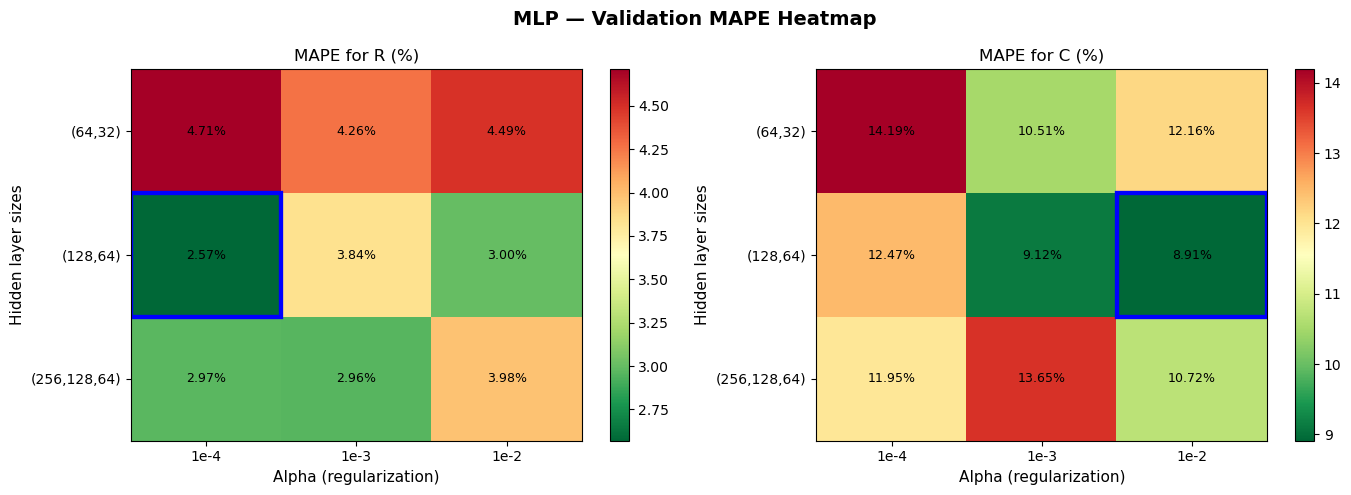

In [26]:
# val MAPE data (rows = hidden_layer_sizes, cols = alpha)
val_mape_r = np.array([
    [4.71, 4.26, 4.49],   # (64, 32)
    [2.57, 3.84, 3.00],   # (128, 64)
    [2.97, 2.96, 3.98],   # (256, 128, 64)
])

val_mape_c = np.array([
    [14.19, 10.51, 12.16],  # (64, 32)
    [12.47,  9.12,  8.91],  # (128, 64)
    [11.95, 13.65, 10.72],  # (256, 128, 64)
])

hidden_labels = ['(64,32)', '(128,64)', '(256,128,64)']
alpha_labels  = ['1e-4', '1e-3', '1e-2']

# best configuration: (128, 64), alpha=1e-2 (lowest avg mape)
best_row_c = 1  # (128, 64)
best_col_c = 2  # alpha=1e-2

best_row_r = 1  # (128, 64)
best_col_r = 0  # alpha=1e-2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLP — Validation MAPE Heatmap', fontsize=14, fontweight='bold')

for ax, data, title in zip(
    [ax1, ax2],
    [val_mape_r, val_mape_c],
    ['MAPE for R (%)', 'MAPE for C (%)']
):
    im = ax.imshow(data, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(alpha_labels)))
    ax.set_yticks(range(len(hidden_labels)))
    ax.set_xticklabels(alpha_labels)
    ax.set_yticklabels(hidden_labels)
    ax.set_xlabel('Alpha (regularization)', fontsize=11)
    ax.set_ylabel('Hidden layer sizes', fontsize=11)
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax)

    # annotate each cell
    for i in range(len(hidden_labels)):
        for j in range(len(alpha_labels)):
            ax.text(j, i, f'{data[i,j]:.2f}%',
                   ha='center', va='center', fontsize=9, color='black')

    # highlight best cell
    ax2.add_patch(plt.Rectangle(
        (best_col_c - 0.5, best_row_c - 0.5), 1, 1,
        fill=False, edgecolor='blue', linewidth=3
    ))
    # highlight best cell
    ax1.add_patch(plt.Rectangle(
        (best_col_r - 0.5, best_row_r - 0.5), 1, 1,
        fill=False, edgecolor='blue', linewidth=3
    ))

plt.tight_layout()
plt.savefig('mlp_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Model comparison

The table below compares all three models on the **test set** using MAE and RMSE for R (Ω) and C (F), plus total time (training + test inference). The best hyperparameters were selected using the **validation set only**.

In [18]:
target_is_log = globals().get('target_is_log', False)
y_test_phys = np.exp(y_test) if target_is_log else y_test

def to_phys(y_pred, is_log):
    return np.exp(y_pred) if is_log else y_pred

def metrics_r_c(y_true, y_pred):
    mae_r = mean_absolute_error(y_true[:, 0], y_pred[:, 0])
    mae_c = mean_absolute_error(y_true[:, 1], y_pred[:, 1])
    rmse_r = np.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))
    rmse_c = np.sqrt(mean_squared_error(y_true[:, 1], y_pred[:, 1]))
    mape_r = mean_absolute_percentage_error(y_true[:, 0], y_pred[:, 0]) * 100
    mape_c = mean_absolute_percentage_error(y_true[:, 1], y_pred[:, 1]) * 100
    return mae_r, mae_c, rmse_r, rmse_c, mape_r, mape_c

# Measure test-set inference time for each best model
t0 = time.perf_counter(); lr_test_pred  = to_phys(lr_model.predict(X_test),    target_is_log); infer_time_lr  = time.perf_counter() - t0
t0 = time.perf_counter(); rf_test_pred  = to_phys(best_model.predict(X_test),  target_is_log); infer_time_rf  = time.perf_counter() - t0
t0 = time.perf_counter(); mlp_test_pred = to_phys(mlp_model.predict(X_test),   target_is_log); infer_time_mlp = time.perf_counter() - t0

# Compute test metrics
lr_te  = metrics_r_c(y_test_phys, lr_test_pred)
rf_te  = metrics_r_c(y_test_phys, rf_test_pred)
mlp_te = metrics_r_c(y_test_phys, mlp_test_pred)

# Total time = train + inference
total_time_lr  = train_time_lr  + infer_time_lr
total_time_rf  = train_time_rf  + infer_time_rf
total_time_mlp = train_time_mlp + infer_time_mlp

rows = [
    {"Method": "Linear Regression (Ridge)",
     "MAE (R)": lr_te[0],   "MAE (C)": lr_te[1],
     "RMSE (R)": lr_te[2],  "RMSE (C)": lr_te[3],
     "MAPE (R)": lr_te[4],  "MAPE (C)": lr_te[5],
     "Time (s)": total_time_lr},
    {"Method": "Random Forest",
     "MAE (R)": rf_te[0],   "MAE (C)": rf_te[1],
     "RMSE (R)": rf_te[2],  "RMSE (C)": rf_te[3],
     "MAPE (R)": rf_te[4],  "MAPE (C)": rf_te[5],
     "Time (s)": total_time_rf},
    {"Method": "MLP",
     "MAE (R)": mlp_te[0],  "MAE (C)": mlp_te[1],
     "RMSE (R)": mlp_te[2], "RMSE (C)": mlp_te[3],
     "MAPE (R)": mlp_te[4], "MAPE (C)": mlp_te[5],
     "Time (s)": total_time_mlp},
]

comparison_df = pd.DataFrame(rows)
fmt = {
    "MAE (R)":  "{:.4f}",
    "RMSE (R)": "{:.4f}",
    "MAE (C)":  "{:.4e}",
    "RMSE (C)": "{:.4e}",
    "MAPE (R)": "{:.2f}%",
    "MAPE (C)": "{:.2f}%",
    "Time (s)": "{:.4f}",
}
display(comparison_df.style.format(fmt).hide(axis="index"))


Method,MAE (R),MAE (C),RMSE (R),RMSE (C),MAPE (R),MAPE (C),Time (s)
Linear Regression (Ridge),94.1966,1.4024e-07,137.9576,3.5513e-07,8.74%,12.49%,0.0542
Random Forest,20.5594,8.8333e-08,31.0981,2.9178e-07,2.64%,8.64%,188.2263
MLP,30.6349,1.2720e-07,46.7943,3.1788e-07,2.52%,11.61%,3.3533


## Best hyperparameters per model

The table below summarises the best hyperparameter configuration found for each model (chosen by lowest average validation MAE across R and C), along with data quantities and training time.

In [27]:
n_train, n_val, n_test = len(X_train), len(X_val), len(X_test)
data_str = f"({n_train}, {n_val}, {n_test})"

summary_rows = [
    {
        "Model": "Linear Regression (Ridge)",
        "Best hyperparameters": f"alpha={best_lr_params.get('alpha', '—')}",
        "Data (n_train, n_val, n_test)": data_str,
        "Train time (s)": train_time_lr,
    },
    {
        "Model": "Random Forest",
        "Best hyperparameters": (
            f"n_estimators={best_rf_params.get('n_estimators', '—')}, "
            f"max_depth={best_rf_params.get('max_depth', '—')}"
        ),
        "Data (n_train, n_val, n_test)": data_str,
        "Train time (s)": train_time_rf,
    },
    {
        "Model": "MLP",
        "Best hyperparameters": (
            f"hidden_layer_sizes={best_mlp_params.get('hidden_layer_sizes', '—')}, "
            f"alpha={best_mlp_params.get('alpha', '—')}"
        ),
        "Data (n_train, n_val, n_test)": data_str,
        "Train time (s)": train_time_mlp,
    },
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.format({"Train time (s)": "{:.4f}"}).hide(axis="index"))


Model,Best hyperparameters,"Data (n_train, n_val, n_test)",Train time (s)
Linear Regression (Ridge),alpha=1.0,"(1400, 300, 300)",0.0493
Random Forest,"n_estimators=200, max_depth=20","(1400, 300, 300)",187.1967
MLP,"hidden_layer_sizes=(128, 64), alpha=0.0001","(1400, 300, 300)",3.9704


## Hybrid ML + Gauss-Newton

### How the models are combined

The best ML model (Random Forest) is used as a **warm-start initializer** for the Gauss-Newton (GN) parameter estimator from `CircuitSimulator`:

1. **Step 1 - ML prediction:** Random Forest predicts initial estimates of R and C directly from the flattened waveform features. This is instantaneous and requires no knowledge of the circuit equations.
2. **Step 2 - Gauss-Newton refinement:** The predicted (R, C) are passed as the starting point to `CircuitSimulator.GaussNewton`, which minimizes the residual between the circuit-simulated waveform and the actual observed waveform. At each iteration it:
   - Runs a full Backward Euler simulation with the current (R, C) guess.
   - Computes the sensitivity (Jacobian) of each simulated signal with respect to R and C.
   - Updates (R, C) via the multiplicative GN step: beta = (J^T J)^-1 J^T r, then R *= exp(beta[0]), C *= exp(beta[1]).

### Why this combination improves accuracy

| Problem with ML alone | How Gauss-Newton corrects it |
|---|---|
| Predictions are unconstrained - ML may output physically inconsistent (R, C) | GN enforces physics: the final answer must be consistent with the circuit ODE |
| ML generalises from training data; waveform shapes outside the training distribution degrade accuracy | GN minimises waveform residuals directly, so it adapts to each individual sample |
| ML has systematic bias from limited training data | GN iteratively reduces residuals toward zero |
| Gauss-Newton alone is sensitive to initialisation and can diverge | ML provides a close warm start, making GN converge faster and reliably |

### Trade-offs

- **Computation:** Much slower than ML alone - each GN iteration requires a full Backward Euler simulation per sample.
- **Dependencies:** Requires the physics simulator and physical-unit waveforms (the dataset is stored standardized, so unstandardization must be applied before calling GN).
- **Best use case:** High-accuracy post-processing of a small number of predictions where accuracy matters more than throughput.


In [28]:
from circuit_simulator import CircuitSimulator

# Circuit simulation constants (matching dataset generation in test.py)
AMPLITUDE = 5.0
FREQUENCY = 60.0
DELTA_T   = 1e-4
# Use first 100 steps to keep each GN call fast (~0.5 s / sample)
N_STEPS   = 100
# Tiny epsilon avoids an off-by-one due to float rounding in BEuler's while(t < T)
T_SUB     = N_STEPS * DELTA_T - 1e-12

def unstandardize(waveform_std, mu, sigma):
    """Convert standardized (T,4) waveform back to physical units."""
    if mu is None or sigma is None:
        return waveform_std
    return waveform_std * sigma[0] + mu[0]

# If the load-data cell wasn't rerun, pull waveforms/scaling directly from the pickle
try:
    X_test_ts
except NameError:
    import pickle
    with open('group_5_dataset.pkl', 'rb') as f:
        _data_gn = pickle.load(f)
    X_test_ts = _data_gn['X_test']
    mu = _data_gn.get('mu', None)
    sigma = _data_gn.get('sigma', None)

target_is_log = globals().get('target_is_log', False)
sample_indices = [0, 1, 2, 3, 4]

# RF predictions (physical units) for the chosen test samples
rf_init = to_phys(best_model.predict(X_test[sample_indices]), target_is_log)
y_true_phys = np.exp(y_test[sample_indices]) if target_is_log else y_test[sample_indices]

hybrid_rows = []
for j, idx in enumerate(sample_indices):
    R_true, C_true = y_true_phys[j, 0], y_true_phys[j, 1]
    R_ml,   C_ml   = rf_init[j, 0],     rf_init[j, 1]

    # Unstandardize waveform back to physical units, then truncate to N_STEPS
    waveform = unstandardize(X_test_ts[idx], mu, sigma)[:N_STEPS]

    # Run Gauss-Newton starting from ML prediction
    mna = CircuitSimulator(AMPLITUDE, FREQUENCY, R_ml, C_ml)
    R_hybrid, C_hybrid, _ = mna.GaussNewton(
        R_ml, C_ml, np.zeros(4), waveform, DELTA_T, T_SUB, max_iter=10
    )

    hybrid_rows.append({
        "idx":            idx,
        "R_true":         R_true,
        "C_true":         C_true,
        "R_ml":           R_ml,
        "C_ml":           C_ml,
        "R_hybrid":       R_hybrid,
        "C_hybrid":       C_hybrid,
        "|err_R| ML":     abs(R_ml     - R_true),
        "|err_R| Hybrid": abs(R_hybrid - R_true),
        "|err_C| ML":     abs(C_ml     - C_true),
        "|err_C| Hybrid": abs(C_hybrid - C_true),
    })

hybrid_df = pd.DataFrame(hybrid_rows).set_index("idx")
fmt_h = {
    "R_true": "{:.2f}", "R_ml": "{:.2f}", "R_hybrid": "{:.2f}",
    "|err_R| ML": "{:.4f}", "|err_R| Hybrid": "{:.4f}",
    "C_true": "{:.4e}", "C_ml": "{:.4e}", "C_hybrid": "{:.4e}",
    "|err_C| ML": "{:.4e}", "|err_C| Hybrid": "{:.4e}",
}
print(f"Hybrid ML + Gauss-Newton: parameter estimation on {len(sample_indices)} test samples")
print(f"(GN uses first {N_STEPS} time steps, max_iter=10, warm-started from Random Forest)")
display(hybrid_df.style.format(fmt_h))

mae_r_ml     = hybrid_df["|err_R| ML"].mean()
mae_r_hybrid = hybrid_df["|err_R| Hybrid"].mean()
mae_c_ml     = hybrid_df["|err_C| ML"].mean()
mae_c_hybrid = hybrid_df["|err_C| Hybrid"].mean()
print(f"\nMean |err R|: ML = {mae_r_ml:.4f} ohm  -->  Hybrid = {mae_r_hybrid:.4f} ohm  "
      f"({'improved' if mae_r_hybrid < mae_r_ml else 'no improvement'})")
print(f"Mean |err C|: ML = {mae_c_ml:.4e} F    -->  Hybrid = {mae_c_hybrid:.4e} F    "
      f"({'improved' if mae_c_hybrid < mae_c_ml else 'no improvement'})")


Number of iterations: 10.
Number of iterations: 10.
Number of iterations: 10.
Number of iterations: 10.
Number of iterations: 10.
Hybrid ML + Gauss-Newton: parameter estimation on 5 test samples
(GN uses first 100 time steps, max_iter=10, warm-started from Random Forest)


,R_true,C_true,R_ml,C_ml,R_hybrid,C_hybrid,|err_R| ML,|err_R| Hybrid,|err_C| ML,|err_C| Hybrid
idx,,,,,,,,,,
0,1350.59,3.2323e-07,1320.67,2.8807e-07,1520.32,2.9655e-07,29.9208,169.7252,3.5168e-08,2.6688e-08
1,2204.25,1.5522e-07,2185.07,1.4840e-07,2093.64,1.7291e-07,19.1781,110.6067,6.8187e-09,1.7689e-08
2,2406.40,1.5091e-06,2346.20,1.5067e-06,2560.32,1.4199e-06,60.1965,153.9224,2.3903e-09,8.9214e-08
3,1114.44,3.3354e-06,1123.38,3.3583e-06,1168.35,3.1761e-06,8.9384,53.9028,2.2839e-08,1.5934e-07
4,361.35,2.3552e-07,360.09,2.1756e-07,352.87,1.1499e-07,1.2550,8.4802,1.7960e-08,1.2053e-07



Mean |err R|: ML = 23.8978 ohm  -->  Hybrid = 99.3275 ohm  (no improvement)
Mean |err C|: ML = 1.7035e-08 F    -->  Hybrid = 8.2693e-08 F    (no improvement)
